In [1]:
from typing import Dict, TypedDict, Literal
from langgraph.graph import StateGraph, END, START
from langchain_core.prompts import ChatPromptTemplate
from langchain_openai import ChatOpenAI
from langchain_core.output_parsers import StrOutputParser

from IPython.display import display, Image
from langchain_core.runnables.graph import MermaidDrawMethod
from pydantic import BaseModel, Field
from dotenv import load_dotenv
import os

load_dotenv()

True

In [2]:
class State(TypedDict):
    query: str
    category: str
    confidence: float
    sentiment: str
    response: str
    quality_score: float


llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

parser = StrOutputParser()

In [3]:
class QueryCategorySchema(BaseModel):
    category: Literal["Technical", "Billing", "General"] = Field(..., description="The category of the customer query: Technical, Billing, or General.")
    confidence: float = Field(..., ge=0.0, le=1.0, description="Confidence score between 0.0 and 1.0 for the category classification.")

class QualityCheckSchema(BaseModel):
    quality_score: float = Field(..., ge=0.0, le=1.0, description="Quality score between 0.0 and 1.0. Score above 0.7 means the response is helpful and addresses the query.")
    feedback: str = Field(..., description="Brief feedback on why the response is or isn't helpful.")

class SentimentAnalysisSchema(BaseModel):
    sentiment: Literal["Positive", "Neutral", "Negative"] = Field(..., description="The sentiment of the customer query: Positive, Neutral, or Negative.")

def categorize(state: State) -> State:
    """Categorize the customer query into Technical, Billing, or General."""
    prompt = ChatPromptTemplate.from_messages([
        ("system", "Categorize the following customer query into one of these categories: Technical, Billing, General. Also provide a confidence score between 0.0 and 1.0."),
        ("user", "Query: {query}")
    ])
    chain = prompt | llm.with_structured_output(QueryCategorySchema)
    result = chain.invoke({"query": state["query"]})
    return {
        "category": result.category,
        "confidence": result.confidence, 
    }

def analyze_sentiment(state: State) -> State:
    """Analyze the sentiment of the customer query as Positive, Neutral, or Negative."""
    prompt = ChatPromptTemplate.from_messages([
        ("system", "Analyze the sentiment of the following customer query. Respond with either 'Positive', 'Neutral', or 'Negative'."),
        ("user", "Query: {query}")
    ])
    chain = prompt | llm.with_structured_output(SentimentAnalysisSchema)
    sentiment = chain.invoke({"query": state["query"]})
    return {"sentiment": sentiment.sentiment}

def handle_technical(state: State) -> State:
    """Provide a technical support response to the query."""
    prompt = ChatPromptTemplate.from_messages([
        ("system", "Provide a technical support response to the following query."),
        ("user", "Query: {query}")
    ])
    chain = prompt | llm | parser
    response = chain.invoke({"query": state["query"]})
    return {"response": response}

def handle_billing(state: State) -> State:
    """Provide a billing support response to the query."""
    prompt = ChatPromptTemplate.from_messages([
        ("system", "Provide a billing support response to the following query."),
        ("user", "Query: {query}")
    ])
    chain = prompt | llm | parser
    response = chain.invoke({"query": state["query"]})
    return {"response": response}

def handle_general(state: State) -> State:
    """Provide a general support response to the query."""
    prompt = ChatPromptTemplate.from_messages([
        ("system", "Provide a general support response to the following query."),
        ("user", "Query: {query}")
    ])
    chain = prompt | llm | parser
    response = chain.invoke({"query": state["query"]})
    return {"response": response}

def escalate(state: State) -> State:
    """Escalate the query to a human agent due to negative sentiment."""
    return {"response": "This query has been escalated to a human agent due to its negative sentiment."}

def quality_check(state: State) -> State:
    """Check if the generated response is helpful and relevant to the query."""
    prompt = ChatPromptTemplate.from_messages([
        ("system", """You are a quality assurance reviewer for customer support responses.
Score the response on a scale of 0.0 to 1.0 based on:
- Does it directly address the query?
- Is it helpful and actionable?
- Is it professional and clear?"""),
        ("user", "Query: {query}\n\nResponse: {response}")
    ])
    chain = prompt | llm.with_structured_output(QualityCheckSchema)
    result = chain.invoke({
        "query": state["query"],
        "response": state["response"]
    })
    return {"quality_score": result.quality_score}


def regenerate_response(state: State) -> State:
    """Regenerate a better response if quality check failed."""
    prompt = ChatPromptTemplate.from_messages([
        ("system", """The previous response was not helpful enough.
Generate a better, more detailed and actionable response.
Category: {category}"""),
        ("user", "Query: {query}\n\nPrevious response that was not good enough: {response}")
    ])
    chain = prompt | llm | parser
    new_response = chain.invoke({
        "query": state["query"],
        "response": state["response"],
        "category": state["category"]
    })
    return {"response": new_response}

def route_query(state: State) -> str:
    """Route based on sentiment, then category, then confidence."""
    if state["sentiment"] == "Negative":
        return "escalate"
    elif state["confidence"] < 0.7:
        # ← if not confident enough, treat as general
        return "handle_general"
    elif state["category"] == "Technical":
        return "handle_technical"
    elif state["category"] == "Billing":
        return "handle_billing"
    else:
        return "handle_general"
    
def route_quality(state: State) -> str:
    """Route based on quality score — regenerate if below threshold."""
    if state["quality_score"] < 0.7:
        return "regenerate_response"
    else:
        return END

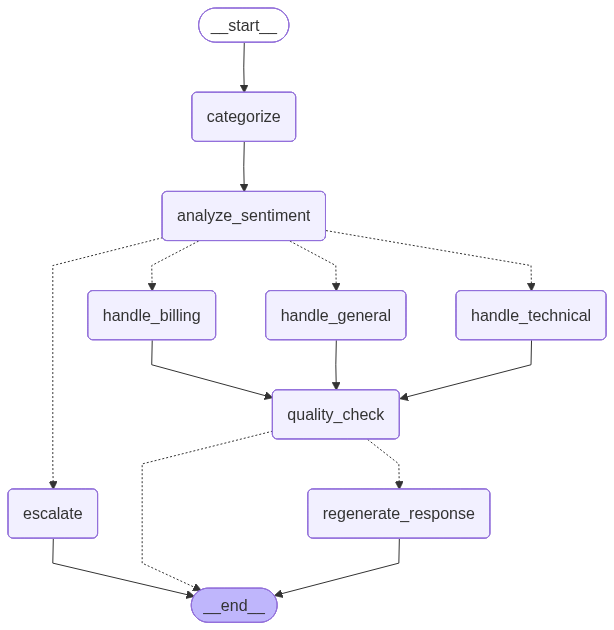

In [4]:
# Create the graph
workflow = StateGraph(State)

# Add nodes
workflow.add_node("categorize", categorize)
workflow.add_node("analyze_sentiment", analyze_sentiment)
workflow.add_node("handle_technical", handle_technical)
workflow.add_node("handle_billing", handle_billing)
workflow.add_node("handle_general", handle_general)
workflow.add_node("escalate", escalate)
workflow.add_node("quality_check", quality_check)          # ← new
workflow.add_node("regenerate_response", regenerate_response)  # ← new

# Add edges
workflow.add_edge(START, "categorize")
workflow.add_edge("categorize", "analyze_sentiment")
workflow.add_conditional_edges(
    "analyze_sentiment",
    route_query,
    {
        "handle_technical": "handle_technical",
        "handle_billing": "handle_billing",
        "handle_general": "handle_general",
        "escalate": "escalate"
    }
)

# All handlers go to quality_check instead of END
workflow.add_edge("handle_technical", "quality_check")     # ← changed
workflow.add_edge("handle_billing", "quality_check")       # ← changed
workflow.add_edge("handle_general", "quality_check")       # ← changed
workflow.add_edge("escalate", END)                         # ← escalate skips quality check

# Quality check either ends or regenerates
workflow.add_conditional_edges(
    "quality_check",
    route_quality,
    {
        "regenerate_response": "regenerate_response",
        END: END
    }
)
workflow.add_edge("regenerate_response", END)              # ← regenerate always ends

# Compile
app = workflow.compile()
app

In [5]:
# Should pass quality check
result = app.invoke({"query": "How do I reset my password?"})
print(f"Category: {result['category']}, Quality: {result['quality_score']}")
print(f"Response: {result['response']}")

# Check quality score
print(f"\nQuality score: {result['quality_score']}")
print("Regenerated:" , result['quality_score'] < 0.7)

Category: Technical, Quality: 1.0
Response: To reset your password, please follow these steps:

1. **Visit the Login Page**: Go to the login page of the application or website where you need to reset your password.

2. **Click on 'Forgot Password?'**: Look for a link or button that says "Forgot Password?" or "Reset Password" and click on it.

3. **Enter Your Email Address**: You will be prompted to enter the email address associated with your account. Make sure to enter it correctly.

4. **Check Your Email**: After submitting your email address, check your inbox for a password reset email. If you don’t see it, please check your spam or junk folder.

5. **Follow the Instructions**: Open the email and follow the instructions provided. This usually involves clicking a link that will take you to a password reset page.

6. **Create a New Password**: On the password reset page, enter your new password. Make sure it meets any specified requirements (such as length, special characters, etc.).


In [6]:
# Ambiguous query — should fall back to general
result = app.invoke({"query": "I need some help"})
print(f"Category: {result['category']}, Confidence: {result['confidence']}, Sentiment: {result['sentiment']}")
print(f"Response: {result['response']}")

Category: General, Confidence: 0.8, Sentiment: Neutral
Response: Of course! I'm here to help. Please let me know what you need assistance with, and I'll do my best to provide the information or support you're looking for.
